###Μηχανική Μάθηση
####2η ατομική εργασία
ΣΗΜΜΥ- ΕΜΠ - 7ο εξάμηνο -Ακ. Έτος 2023-24



# ⚠️
`Επισημαίνεται ότι απαγορεύεται η ανάρτηση των λύσεων των εργαστηριακών ασκήσεων στο github, ή σε άλλες ιστοσελίδες. Η σχεδίαση και το περιεχόμενο των εργαστηριακών projects αποτελούν αντικείμενο πνευματικής ιδιοκτησίας της διδακτικής ομάδας του μαθήματος.`

### Εισαγωγή

Στην άσκηση αυτή θα εξερευνήσετε τεχνικές συσταδοποίησης και μείωσης διαστατικότητας σε εικόνες, ξεκινώντας από υπερφασματικά δεδομένα και προχωρώντας σε δεδομένα τηλεπισκόπησης.

- **Μέρος 1**: Θα χρησιμοποιήσετε τη μέθοδο συσταδοποίησης **k-means**, καθώς και την **fuzzy c-means**, σε συνδυασμό με τη μέθοδο μείωσης διαστατικότητας **PCA**, για την ανάλυση μιας υπερφασματικής εικόνας.

- **Μέρος 2**: Θα εργαστείτε με ένα σύνολο δεδομένων τηλεπισκόπησης και, με τη βοήθεια ενός προεκπαιδευμένου CNN, θα εξάγετε χαρακτηριστικά εικόνων για συσταδοποίηση, συγκρίνοντας τα αποτελέσματα με τη συσταδοποίηση με χρήση των pixels.

Ονοματεπώνυμο φοιτητή: Δημήτριος Θανόγιαννης

Α.Μ.: 03121902

### 1. Φόρτωση υπερφασματικής εικόνας και των επισημειώσεων της

Κατεβάστε την υπερφασματική εικόνα `salinas_image.npy` και τις αντίστοιχες επισημειώσεις `salinas_labels.npy` από το Google Drive:
https://drive.google.com/drive/folders/1DAKjz0IZkaorrHykD8R0KJctpMBRLqSs?usp=sharing

1.α. Φορτώστε την εικόνα και τις αντίστοιχες επισημειώσεις με χρήση της συνάρτησης np.load.

Οι επισημειώσεις που φορτώσατε αντιστοιχούν κάθε πιξελ της υπερφασματικής εικόνας σε ένα τύπο από 16 διαφορετικές κατηγορίες:

```python
classes = [
    "Background",
    "Broccoli_green_weeds_1",
    "Broccoli_green_weeds_2",
    "Fallow",
    "Fallow_rough_plow",
    "Fallow_smooth",
    "Stubble",
    "Celery",
    "Grapes_untrained",
    "Soil_vineyard_develop",
    "Corn_senesced_green_weeds",
    "Lettuce_romaine_4wk",
    "Lettuce_romaine_5wk",
    "Lettuce_romaine_6wk",
    "Lettuce_romaine_7wk",
    "Vineyard_untrained",
    "Vineyard_vertical_trellis"
]
```

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import matplotlib.patches as mpatches
import pandas as pd
import random
from google.colab import files

uploaded = files.upload()

img = np.load('salinas_image.npy')
labels = np.load('salinas_labels.npy')

Saving salinas_image.npy to salinas_image (1).npy
Saving salinas_labels.npy to salinas_labels (1).npy


### 2. Οπτικοποίηση και Διερευνητική ανάλυση δεδομένων

Παρουσιάστε με χρήση κώδικα πληροφορίες για τα εξής:

2α. Βρείτε το ύψος και το πλάτος της εικόνας, καθώς και τον αριθμό των υπερφασματικών καναλιών

2β. Σχεδιάστε με χρήση της matplotlib το 3ο, 65ο, και 95ο κανάλι της εικόνας στο ίδιο διάγραμμα

2γ. Υπολογίστε τον αριθμό των διαφορετικών κατηγοριών καλλιέργειας στις επισημειώσεις

2δ. Σχεδιάστε με χρήση της matplotlib τις επισημειώσεις. Προσθέστε επιπλέον επεξηγηματική λεζάντα με χρήση της βιβλιοθήκης κάθε επισημείωσης (χρησιμοποιήστε τη λίστα `classes` που σας δόθηκε προηγουμένως.)

2ε. Υπολογίστε πόσα pixel της εικόνας αντιστοιχούν σε κάθε επισημείωση.

In [ ]:
image = img.transpose((2, 0, 1))
np.shape(image)

(204, 512, 217)

Παρατηρούμε ότι η εικόνα έχει διαστάσεις 512x217 και ο αριθμός των υπερφασματικών καναλιών είναι 204.

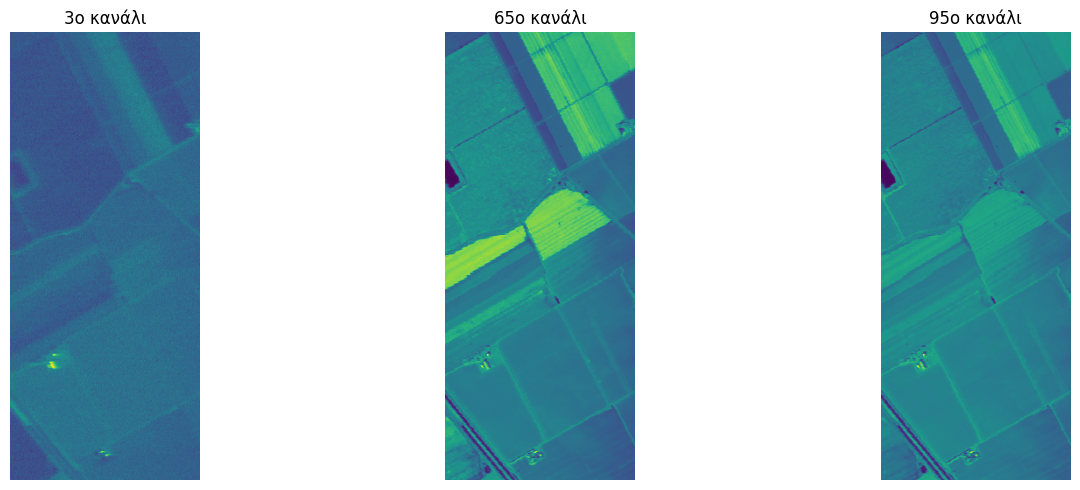

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

channels = [2, 64, 94]
titles = ["3ο κανάλι", "65ο κανάλι", "95ο κανάλι"]

for i, ax in enumerate(axes):
    ax.imshow(image[channels[i]], cmap='viridis')
    ax.set_title(titles[i])
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
values = np.unique(labels.ravel())
values_cnt = len(values)
print(f"There are {values_cnt} unique crop types in the given labels.")

There are 17 unique crop types in the given labels.


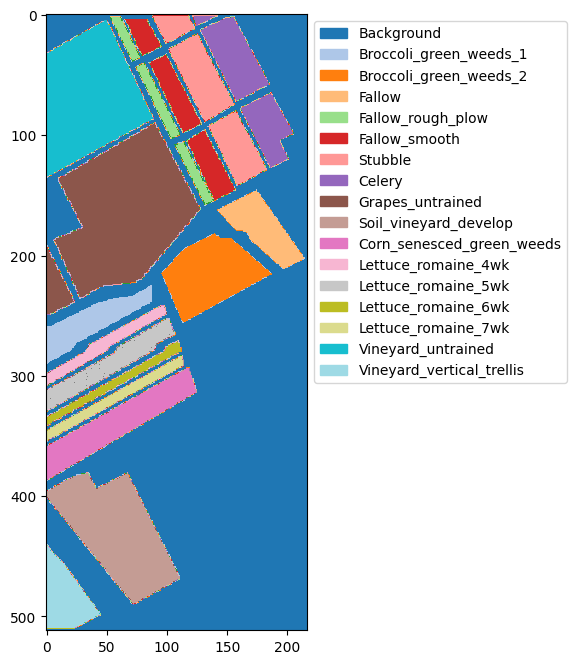

In [ ]:
plt.figure(figsize = (5,8))
im = plt.imshow(labels, cmap = 'tab20')

colors = [im.cmap(im.norm(value)) for value in values]

classes = [
    "Background",
    "Broccoli_green_weeds_1",
    "Broccoli_green_weeds_2",
    "Fallow",
    "Fallow_rough_plow",
    "Fallow_smooth",
    "Stubble",
    "Celery",
    "Grapes_untrained",
    "Soil_vineyard_develop",
    "Corn_senesced_green_weeds",
    "Lettuce_romaine_4wk",
    "Lettuce_romaine_5wk",
    "Lettuce_romaine_6wk",
    "Lettuce_romaine_7wk",
    "Vineyard_untrained",
    "Vineyard_vertical_trellis"
]

patches = [mpatches.Patch(color=colors[i], label = classes[i]) for i in range(values_cnt)]
plt.legend(handles=patches, bbox_to_anchor=(1, 1), loc=2)

plt.show()

In [ ]:
pixel_count = []
for i in range(values_cnt):
  pixel_count.append(labels.flatten().tolist().count(i))
  print('There are', pixel_count[i], 'pixels with', classes[i])

There are 56975 pixels with Background
There are 2009 pixels with Broccoli_green_weeds_1
There are 3726 pixels with Broccoli_green_weeds_2
There are 1976 pixels with Fallow
There are 1394 pixels with Fallow_rough_plow
There are 2678 pixels with Fallow_smooth
There are 3959 pixels with Stubble
There are 3579 pixels with Celery
There are 11271 pixels with Grapes_untrained
There are 6203 pixels with Soil_vineyard_develop
There are 3278 pixels with Corn_senesced_green_weeds
There are 1068 pixels with Lettuce_romaine_4wk
There are 1927 pixels with Lettuce_romaine_5wk
There are 916 pixels with Lettuce_romaine_6wk
There are 1070 pixels with Lettuce_romaine_7wk
There are 7268 pixels with Vineyard_untrained
There are 1807 pixels with Vineyard_vertical_trellis


### 3. Εύρεση φασματικών υπογραφών

3.α. Μετατρέψτε την υπερφασματική εικόνα και τις επισημειώσεις σε μορφή κατάλληλη για περαιτέρω επεξεργασία. Η εικόνα θα πρέπει να μετατραπεί σε πίνακα N x Κ, όπου Ν τα pixel και K ο αριθμός των καναλιών. Οι επισημειώσεις αντίστοιχα θα πρέπει να μετατραπούν σε διάνυσμα μήκους Ν.

💡 Χρησιμοποιήστε την `numpy reshape`

In [ ]:
N = 512*217
K = 204
my_image = np.reshape(img, (N, K))
my_labels = labels.flatten()

imag = []    # τα pixel που δεν ανήκουν στο background
labl = []    # τα label που δεν ανήκουν στο background
for i in range(N):
  if (my_labels[i] != 0):
    imag.append(my_image[i])
    labl.append(my_labels[i])

3.β. Επιλέξτε ένα τυχαίο pixel της εικόνα από κάθε κατηγορία, και σχεδιάστε την υπερφασματική υπογραφή των επιλεγμένων πίξελ.

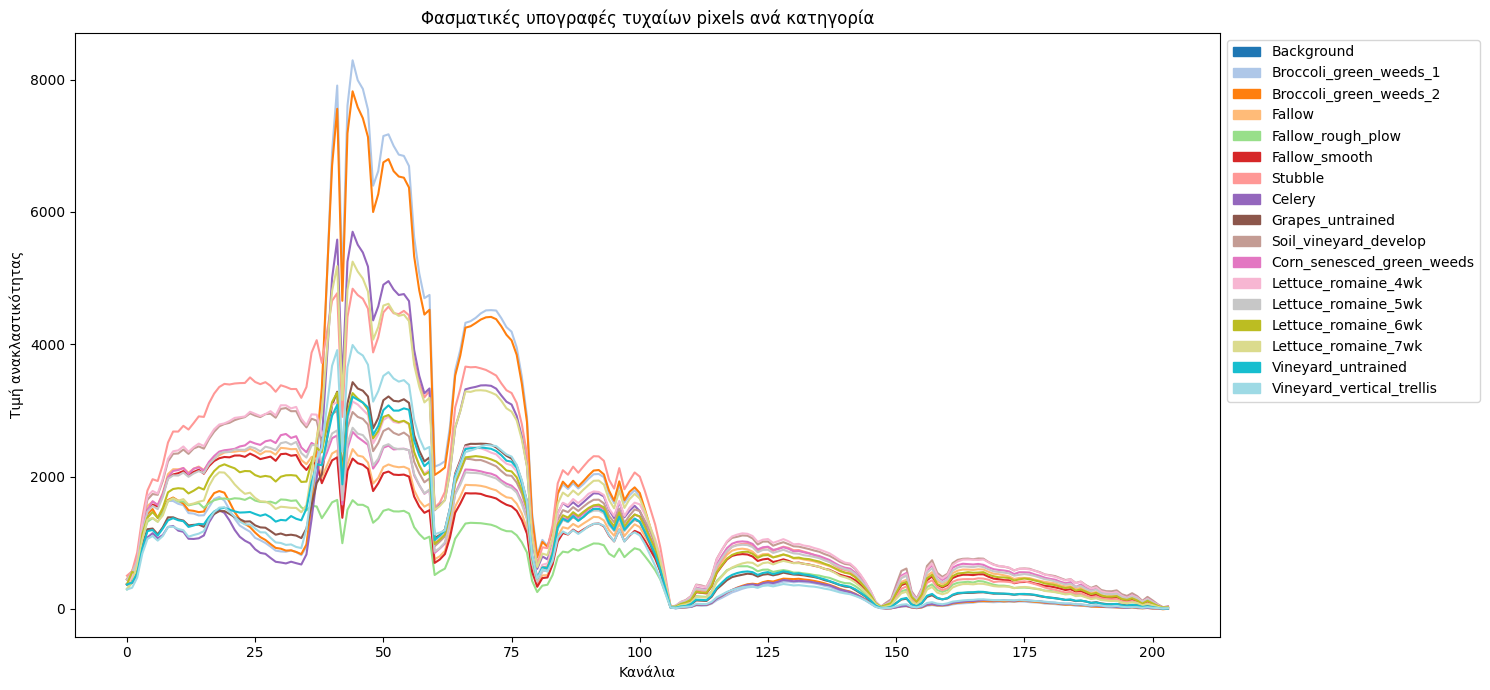

In [ ]:
def spectral_signatures(x):
    random.seed(x)
    random_pixel = ['']
    for i in range(1, values_cnt):
        rnd = random.randrange(pixel_count[i])

        indx = [index for index, num in enumerate(labl) if num == i][rnd]
        random_pixel.append(imag[indx])


    plt.figure(figsize=(15, 7))
    for i in range(1, values_cnt):
        plt.plot(random_pixel[i], c=colors[i])
    plt.legend(handles=patches, bbox_to_anchor=(1, 1), loc=2)
    plt.title("Φασματικές υπογραφές τυχαίων pixels ανά κατηγορία")
    plt.xlabel("Κανάλια")
    plt.ylabel("Τιμή ανακλαστικότητας")
    plt.tight_layout()
    plt.show()

spectral_signatures(2023)

3.γ. Σημειώστε τις παρατηρήσεις σας και τα συμπεράσματα σας. Προσπαθήστε να απαντήσετε στις ακόλουθες ερωτήσεις:
    
* Με βάση τα προηγούμενα διαγράμματα θεωρείτε ότι κάποιες καλλιέργειες είναι πιο εύκολα διαχωρίσιμες από άλλες με βάση τη φασματική υπογραφή τους;
* Θεωρείτε ότι όλα τα κανάλια παρέχουν χρήσιμη πληροφορία για το διαχωρισμό;

Από τα παραπάνω, παρατηρούμε πως κάποιες καλλιέργειες, όπως το μπρόκολο (γαλάζιο και πορτοκαλί) είναι πιο εύκολα διαχωρίσιμες από τις υπόλοιπες, ενώ άλλες, όπως το καλαμπόκι (φούξια) και το μαρούλι 5 εβδομάδων (γκρι) διαχωρίζονται αρκετά πιο δύσκολα σε όλο το φάσμα των καναλιών.

Παρατηρώντας την υπερφασματική υπογραφή των pixel, μπορούμε να παρατηρήσουμε ότι γειτονικά κανάλια έχουν συνήθως παρόμοια πληροφορία, οπότε είναι μικρής χρησιμότητας. Διακρίνουμε τέσσερις ομάδες καναλιών με παρόμοια συμπεριφορά (0-35, 35-80, 80-105, 105-200), κάτι το οποίο επιβεβαιώνεται και από τον ακόλουθο πίνακα συσχέτισης. Τα τελευταία κανάλια είναι λογικό να μην μας δώσουν τόσο σημαντική πληροφορία, αφού οι τιμές για όλες τις καλλιέργειες παρουσιάζουν μικρή απόκλιση.

3.δ. Σχεδιάστε ένα heatmap, που να δείχνει τη συσχέτιση μεταξύ των διαφορετικών καναλιών

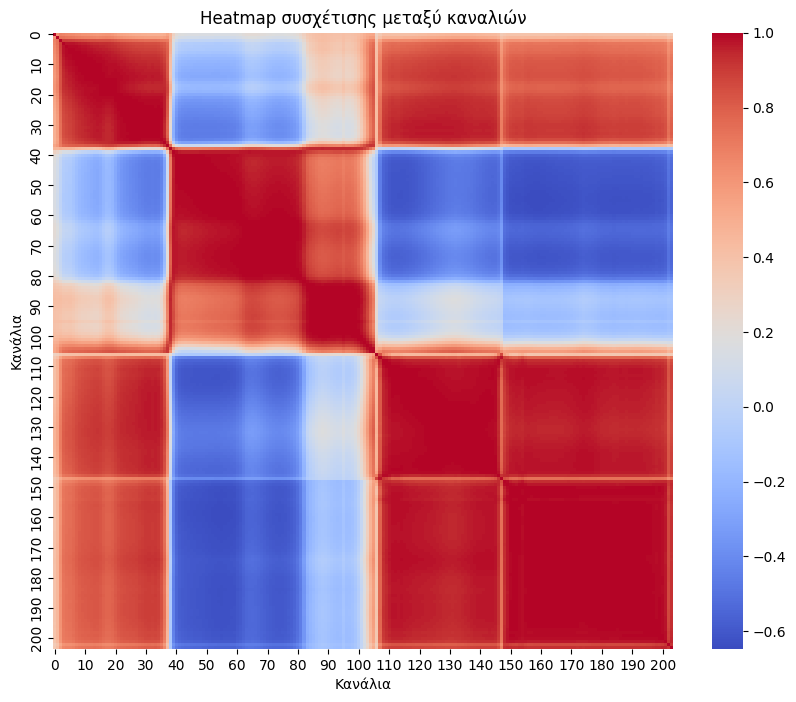

In [ ]:
correlation_matrix = np.corrcoef(np.array(imag).T)

plt.figure(figsize=(10, 8))
sn.heatmap(correlation_matrix, cmap='coolwarm', cbar=True, xticklabels=10, yticklabels=10)
plt.title("Heatmap συσχέτισης μεταξύ καναλιών")
plt.xlabel("Κανάλια")
plt.ylabel("Κανάλια")
plt.show()

### 4. Συσταδοποίηση με χρήση του αλγορίθμου KMeans

 4.α. Εφαρμόστε τον αλγόριθμο KMeans (sklearn.cluster) στα δεδομένα (εφόσον κάνατε την προεπεξεργασία του Βήματος 3). Χρησιμοποιήστε την τιμή `n_cluster=17`.

Αξιολογήστε την απόδοση του αλγορίθμου χρησιμοποιώντας τις ακόλουθες μετρικες:

* Adjusted Rand Index
* Silhouette Score

Ο Adjusted Rand Index (ARI) υπολογίζει πόσα ζεύγη σημείων ταξινομήθηκαν σωστά είτε στην ίδια συστάδα είτε σε διαφορετικές συστάδες χρησιμοποιώντας τις πραγματικές κατηγορίες, λαμβάνοντας υπόψη τυχαίες αντιστοιχίσεις. Έχει τιμές από -1 (πολύ κακή συσταδοποίηση) έως 1 (τέλεια ευθυγράμμιση με τις κατηγορίες), ενώ τιμή 0 υποδηλώνει τυχαία συσταδοποίηση. Είναι χρήσιμο για την αξιολόγηση της ακρίβειας σε δεδομένα με γνωστές κατηγορίες.

Αντιθέτως το  Silhouette Score μετρά πόσο καλά ένα σημείο δεδομένων ταιριάζει στη συστάδα του σε σχέση με τις υπόλοιπες συστάδες. Υπολογίζει τη μέση απόσταση ενός σημείου από τα υπόλοιπα σημεία της ίδιας συστάδας (cohesion) και τη μέση απόσταση από τα σημεία της πλησιέστερης άλλης συστάδας (separation). Το σκορ κυμαίνεται από -1 έως 1, όπου τιμές κοντά στο 1 υποδηλώνουν καλά ορισμένες συστάδες, τιμές κοντά στο 0 σημαίνουν αλληλοεπικαλυπτόμενες συστάδες, ενώ αρνητικές τιμές υποδεικνύουν κακή ανάθεση σε συστάδα.

Ο Silhouette Score είναι ένα μέτρο εσωτερικής αξιολόγησης, που εξετάζει τη συνοχή και τον διαχωρισμό των συστάδων χωρίς να λαμβάνει υπόψη πραγματικές κατηγορίες. Αντίθετα, ο Adjusted Rand Index (ARI) είναι μέτρο εξωτερικής αξιολόγησης, που συγκρίνει τις συστάδες με τις πραγματικές κατηγορίες (ground truth). Η χρήση και των δύο μαζί παρέχει μια συνολική εικόνα της ποιότητας της συσταδοποίησης.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score

kmeans = KMeans(n_clusters=17, random_state=2023, n_init=10)
cluster_labels = kmeans.fit_predict(imag)

ari = adjusted_rand_score(labl, cluster_labels)
print(f"Adjusted Rand Index (ARI): {ari:.4f}")

silhouette = silhouette_score(imag, cluster_labels)
print(f"Silhouette Score: {silhouette:.4f}")

Adjusted Rand Index (ARI): 0.4785
Silhouette Score: 0.4241


4.β. Χρησιμοποιώντας τα αποτελέσματα τις συσταδοποίησης, σχεδιάστε πάλι με χρήση της matplotlib την ταξινόμηση σε μορφή εικόνας, χρησιμοποιώντας για κάθε pixel τη συστάδα στην οποία έχει ανατεθεί.

Συγκρίνετε με την αρχική εικόνα των επισημειώσεων. Τι παρατηρείτε;

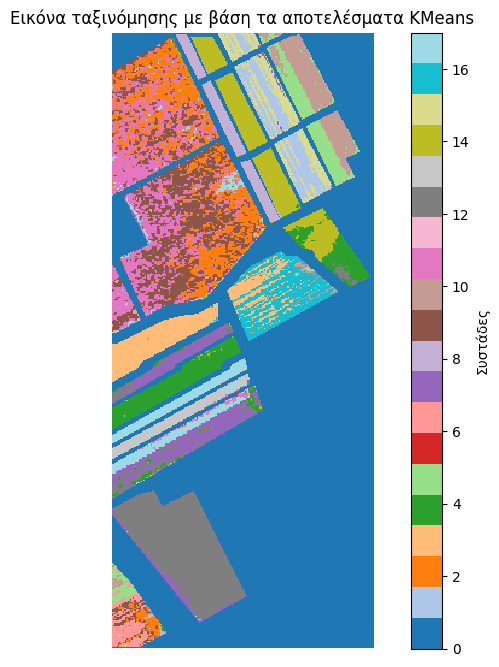

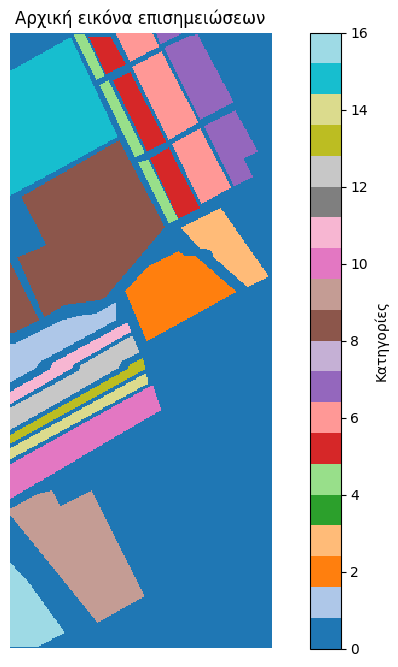

In [ ]:
# Αναδιαμόρφωση των αποτελεσμάτων της συσταδοποίησης (clusters) σε διαστάσεις της αρχικής εικόνας
clustered_image = np.zeros_like(my_labels)
clustered_image[my_labels != 0] = cluster_labels + 1  # Αντιστοίχιση συστάδων (αποφυγή μηδενικού cluster)

# Σχεδίαση ταξινομημένης εικόνας
plt.figure(figsize=(10, 8))
plt.imshow(clustered_image.reshape(labels.shape), cmap='tab20', interpolation='nearest')
plt.title("Εικόνα ταξινόμησης με βάση τα αποτελέσματα KMeans")
plt.axis('off')
plt.colorbar(label="Συστάδες")
plt.show()

# Σχεδίαση αρχικής εικόνας επισημειώσεων για σύγκριση
plt.figure(figsize=(10, 8))
plt.imshow(labels, cmap='tab20', interpolation='nearest')
plt.title("Αρχική εικόνα επισημειώσεων")
plt.axis('off')
plt.colorbar(label="Κατηγορίες")
plt.show()


Συγκρίνοντας τις δύο εικόνες παρατηρούμε πως αν παραλείψουμε τα αμπέλια και τα σταφύλια, οι εικόνες μοιάζουν πάρα πολύ μεταξύ τους. Αυτό σημαίνει πως ο αλγόριθμος k-means με τιμή k = 17 είναι αρκετά καλός για τα συγκεκριμένα δεδομένα. Οι μικρές διαφορές που έχουν οι δύο εικόνες οφείλονται στο γεγονός ότι ο αλγόριθμος k-means δε γνωρίζει τις πραγματικές κατηγορίες (unsupervised).

4.γ. Εφαρμογή του αλγορίθμου Fuzzy C-Means

Ο αλγόριθμος **Fuzzy C-Means** δεν περιλαμβάνεται στο scikit-learn, αλλά μπορούμε να τον εφαρμόσουμε χρησιμοποιώντας τη βιβλιοθήκη `fcmeans`.

#### **Βήμα 1: Εγκατάσταση της βιβλιοθήκης**
Πρώτα, εγκαταστήστε τη βιβλιοθήκη `fcmeans` εκτελώντας την παρακάτω εντολή σε ένα κελί:

```bash
!pip install fuzzy-c-means
```

#### Βήμα 2: Εκτέλεση του αλγορίθμου
Η fcmeans παρέχει λειτουργικότητα αντίστοιχη με τον τρόπο εκπαίδευσης του scikit-learn, επιτρέποντας εύκολη ενσωμάτωση στη ροή εργασιών σας.

Για περισσότερες πληροφορίες σχετικά με τη χρήση της βιβλιοθήκης, δείτε το documentation: https://fuzzy-c-means.readthedocs.io/en/latest/

Υπολογίστε πάλι το Silhouette Score και το ARI και συγκρίνετε με τις προηγούμενες μεθόδους.

Note. Ο αλγόριθμος θα τρέξει περίπου 15 λεπτά.

In [ ]:
!pip install fuzzy-c-means

Adjusted Rand Index (ARI) με Fuzzy C-Means: 0.4712
Silhouette Score με Fuzzy C-Means: 0.3966


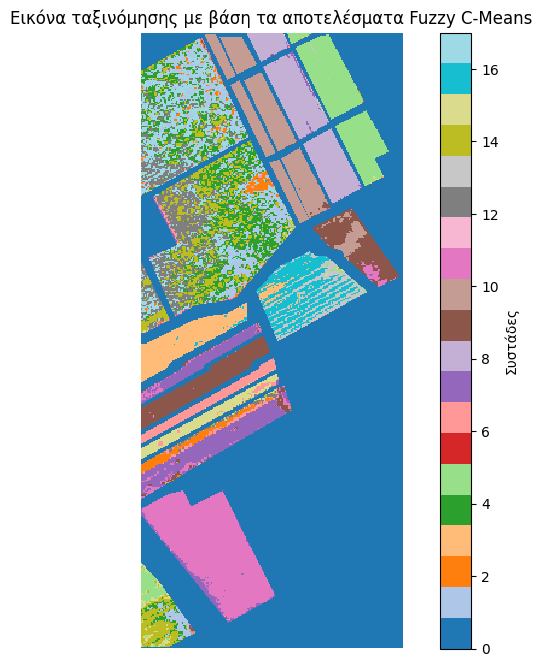

In [ ]:
from fcmeans import FCM

imag = np.array(imag)
labl = np.array(labl)

fcm = FCM(n_clusters=17, random_state=2023)
fcm.fit(imag)

fcm_labels = fcm.predict(imag)

fcm_ari = adjusted_rand_score(labl, fcm_labels)
print(f"Adjusted Rand Index (ARI) με Fuzzy C-Means: {fcm_ari:.4f}")

fcm_silhouette = silhouette_score(imag, fcm_labels)
print(f"Silhouette Score με Fuzzy C-Means: {fcm_silhouette:.4f}")

fcm_clustered_image = np.zeros_like(my_labels)
fcm_clustered_image[my_labels != 0] = fcm_labels + 1

plt.figure(figsize=(10, 8))
plt.imshow(fcm_clustered_image.reshape(labels.shape), cmap='tab20', interpolation='nearest')
plt.title("Εικόνα ταξινόμησης με βάση τα αποτελέσματα Fuzzy C-Means")
plt.axis('off')
plt.colorbar(label="Συστάδες")
plt.show()

Συγκρίνοντας τα αποτελέσματα του fuzzy c-means με αυτά του k-means, παρατηρούμε μόνο μια μικρή διαφορά στη μετρική silhouette score. Συγκεκριμένα, στον fuzzy c-means, η μετρική αυτή έχει μικρότερη τιμή, το οποίο είναι πολύ λογικό, εφόσον ο αλγόριθμος αυτός είναι ασαφούς ομαδοποίησης και η μετρική silhouette score αξιολογεί το διαχωρισμό των συστάδων. Ο k-means είναι αλγόριθμος αυστηρής ομαδοποίησης, επομένως έχει υψηλότερο silhouette score.

### 5. Μείωση διαστατικότητας δεδομένων

5.α. Εφαρμόστε στα δεδομένα τη μέθοδο μείωσης διαστατικότητας PCA. Επιλέξτε `n_components=3`

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
imag3D = pca.fit_transform(imag)

5.β. Τι ποσοστό της διακύμανσης των δεδομένων διατηρείτε με `n_components=3` ?
Hint: sklearn.decomposition.PCA.explained_variance_ratio_

In [ ]:
print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_.cumsum())

[0.75418456 0.22926902 0.01123053]
[0.75418456 0.98345357 0.9946841 ]


Παρατηρούμε πως κρατώντας μόνο 3 διαστάσεις, διατηρείται το 99,4% της διακύμανσης των δεδομένων.

### 6. Συνδυασμός μείωσης διαστατικότητας και kmeans

6.α. Εφαρμόστε τον αλγόριθμο kmeans στα δεδομένα μειωμένης διαστατικότητας `n_components=3`, και υπολογίστε εκ νέου τις μετρικές. Τι συμπεράσματα βγάζετε;

6.β. Δοκιμάστε διαφορετικές τιμές για το n_components (από 1 έως 5) και τρέχτε εκ νέου κάθε φορα τον k-means, υπολογίζοντας τα τελικά score. Για κάθε μετρική, φτιάχτε ένα διάγραμμα που στον άξονα των Χ θα έχει τον αριθμό n_components και στον άξονα των Υ, την τιμή της μετρικής. Τι συμπεράσματα βγάζετε;

In [ ]:
kmeans = KMeans(n_clusters=17, random_state=2023)
kmeans_labels = kmeans.fit_predict(imag3D)

kmeans_ari = adjusted_rand_score(labl, kmeans_labels)
kmeans_silhouette = silhouette_score(imag3D, kmeans_labels)

print(f"Adjusted Rand Index (ARI) με KMeans και PCA (3 διαστάσεις): {kmeans_ari:.4f}")
print(f"Silhouette Score με KMeans και PCA (3 διαστάσεις): {kmeans_silhouette:.4f}")

Adjusted Rand Index (ARI) με KMeans και PCA (3 διαστάσεις): 0.4590
Silhouette Score με KMeans και PCA (3 διαστάσεις): 0.4573


Τα αποτελέσματα δείχνουν πως η μείωση διαστάσεων συμπυκνώνει σημαντικά την πληροφορία, διευκολύνωντας τον αλγόριθμο k-means, χωρίς ταυτόχρονα να παρουσιάζεται αισθητή απώλεια πληροφορίας, όπως ήταν αναμενόμενο.

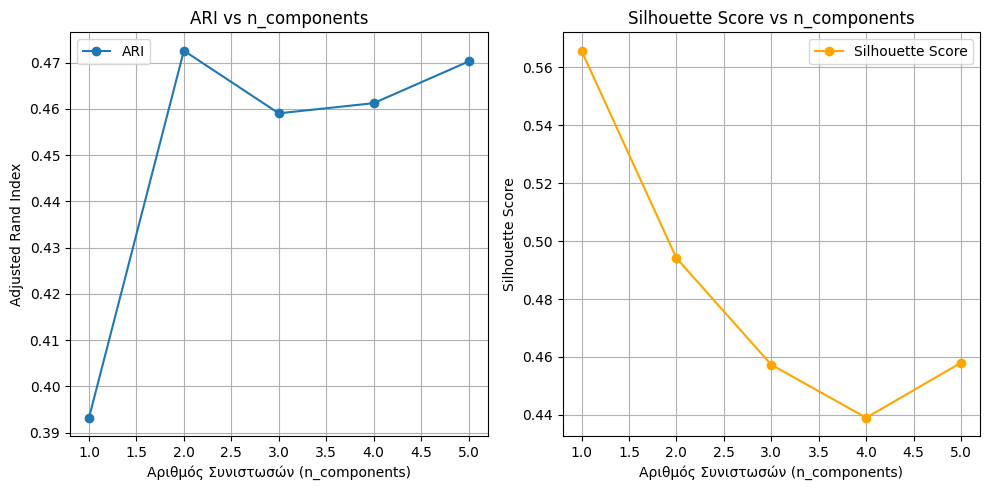

In [ ]:
components = range(1, 6)
ari_scores = []
silhouette_scores = []

for n in components:
    pca = PCA(n_components=n, random_state=2023)
    imag_reduced = pca.fit_transform(imag)

    kmeans = KMeans(n_clusters=17, random_state=2023)
    kmeans_labels = kmeans.fit_predict(imag_reduced)

    ari = adjusted_rand_score(labl, kmeans_labels)
    silhouette = silhouette_score(imag_reduced, kmeans_labels)

    ari_scores.append(ari)
    silhouette_scores.append(silhouette)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(components, ari_scores, marker='o', label="ARI")
plt.title("ARI vs n_components")
plt.xlabel("Αριθμός Συνιστωσών (n_components)")
plt.ylabel("Adjusted Rand Index")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(components, silhouette_scores, marker='o', color='orange', label="Silhouette Score")
plt.title("Silhouette Score vs n_components")
plt.xlabel("Αριθμός Συνιστωσών (n_components)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

Από τα διαγράμματα φαίνεται πως αναφορικά με τον αριθμό των διαστάσεων, οι δύο μετρικές είναι αντιστόφως ανάλογες. Το ARI που λαμβάνει υπόψη του τις πραγματικές κατηγορίες, αποδίδει καλύτερα σε μεγαλύτερες διαστάσεις, ενώ το Silhouette Score, που περιγράφει το πόσο συμπαγείς και διακριτές είναι οι συστάδες, είναι μεγαλύτερο για μικρό αριθμό διαστάσεων. Επομένως για να βελτιστοποιήσουμε την ομαδοποίηση, θα επιλέξουμε μια μέση λύση για τον αριθμό των διαστάσεων. Παρατηρούμε πως το ARI έχει ένα γόνατο στις 2 διαστάσεις, ενώ ταυτόχρονα είναι αρκετά λίγες για να αποδίδει καλά και το Silhouette Score, επομένως η βέλτιστη επιλογή διαστάσεων είναι 2.

# Μέρος 2: Χρήση προεκπαιδευμένου CNN για συσταδοποίηση

Σε αυτό το μέρος, θα χρησιμοποιήσουμε τη βιβλιοθήκη **Keras**, η οποία παρέχει εύκολη ενσωμάτωση προεκπαιδευμένων μοντέλων CNN και ευκολία στη διαχείριση δεδομένων. Στόχος μας είναι να αναδείξουμε τη δύναμη των χαρακτηριστικών που εξάγονται από προεκπαιδευμένα CNN (Convolutional Neural Networks) για τη συσταδοποίηση δεδομένων τηλεπισκόπησης.

Θα χρησιμοποιήσουμε ένα υποσύνολο από το σύνολο δεδομένων **EuroSAT**, το οποίο αποτελείται από δορυφορικές εικόνες κατανεμημένες σε 10 κατηγορίες (π.χ., καλλιέργειες, δάση, αστικές περιοχές). Τα χαρακτηριστικά που θα εξάγουμε από ένα προεκπαιδευμένο CNN θα χρησιμοποιηθούν για την ομαδοποίηση των εικόνων.

---

## 1. Φόρτωση του συνόλου δεδομένων

Για τους σκοπούς αυτής της άσκησης, θα χρησιμοποιήσουμε το σύνολο δεδομένων **EuroSAT**. Το EuroSAT περιλαμβάνει δορυφορικές εικόνες οργανωμένες σε φακέλους κατά κατηγορία.

---

### 1.α. Κατέβασμα και αποσυμπίεση του EuroSAT

Το EuroSAT δεν υποστηρίζεται απευθείας από το Keras, αλλά μπορείτε να το κατεβάσετε και να το αποσυμπιέσετε με τις παρακάτω εντολές:

```bash
# Κατέβασμα του EuroSAT
!wget https://madm.dfki.de/files/sentinel/EuroSAT.zip --no-check-certificate

# Αποσυμπίεση του αρχείου
!unzip EuroSAT.zip
```

### 1.β. Ενσωμάτωση του Keras μέσω TensorFlow
Η βιβλιοθήκη Keras είναι ενσωματωμένη στο TensorFlow. Για να τη χρησιμοποιήσετε, πρέπει να εισάγετε τη βιβλιοθήκη TensorFlow και να χρησιμοποιήσετε τις κλάσεις της Keras μέσω του tensorflow.keras.

Παρακάτω φαίνεται πώς να φορτώσετε το EuroSAT χρησιμοποιώντας το ImageDataGenerator:


In [11]:
!wget https://madm.dfki.de/files/sentinel/EuroSAT.zip --no-check-certificate
! unzip EuroSAT.zip

import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input

data_dir = os.path.join('2750')
print(f'Τα δεδομένα βρίσκονται στο: {data_dir}')

# Κανονικοποίηση και φόρτωση των δεδομένων
datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.90  # φορτώνουμε ένα μικρό μέρος από κάθε κλάση για γρηγορότερα τρεξίματα θέτοντας μεγάλο validation percentage και φορτώνοντας το training
)

dataset = datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224), # το mobilenetv3 δέχεται εικόνες μεγέθους 224 x 224
    batch_size=1, # κάθε κλήση του iterator φορτώνει ένα ζεύγος image - label
    shuffle=False,
    subset='training'
)

print(f'Φορτώθηκαν {len(dataset) * dataset.batch_size} εικόνες.')


Η έξοδος ροής περικόπηκε στις τελευταίες 5000 γραμμές.
  inflating: 2750/SeaLake/SeaLake_263.jpg  
  inflating: 2750/SeaLake/SeaLake_967.jpg  
  inflating: 2750/SeaLake/SeaLake_515.jpg  
  inflating: 2750/SeaLake/SeaLake_1465.jpg  
  inflating: 2750/SeaLake/SeaLake_1817.jpg  
  inflating: 2750/SeaLake/SeaLake_2902.jpg  
  inflating: 2750/SeaLake/SeaLake_2570.jpg  
  inflating: 2750/SeaLake/SeaLake_1004.jpg  
  inflating: 2750/SeaLake/SeaLake_174.jpg  
  inflating: 2750/SeaLake/SeaLake_2111.jpg  
  inflating: 2750/SeaLake/SeaLake_2388.jpg  
  inflating: 2750/SeaLake/SeaLake_1948.jpg  
  inflating: 2750/SeaLake/SeaLake_838.jpg  
  inflating: 2750/SeaLake/SeaLake_2738.jpg  
  inflating: 2750/SeaLake/SeaLake_1999.jpg  
  inflating: 2750/SeaLake/SeaLake_2359.jpg  
  inflating: 2750/SeaLake/SeaLake_2660.jpg  
  inflating: 2750/SeaLake/SeaLake_1775.jpg  
  inflating: 2750/SeaLake/SeaLake_605.jpg  
  inflating: 2750/SeaLake/SeaLake_2201.jpg  
  inflating: 2750/SeaLake/SeaLake_264.jpg  
  infla

---

## 2. Χρήση προεκπαιδευμένου CNN για Εξαγωγή Χαρακτηριστικών

Σε αυτό το βήμα, θα χρησιμοποιήσετε το προεκπαιδευμένο μοντέλο **MobileNetV3Small**, το οποίο είναι διαθέσιμο μέσω της Keras. Το μοντέλο είναι εκπαιδευμένο στο σύνολο δεδομένων **ImageNet** και μπορεί να χρησιμοποιηθεί για την εξαγωγή ισχυρών χαρακτηριστικών από εικόνες. Αυτά τα χαρακτηριστικά θα χρησιμοποιηθούν για τη συσταδοποίηση των δεδομένων.

---

### 2.α. Δημιουργία Εξαγωγέα Χαρακτηριστικών

1. **Φόρτωση του MobileNetV3Small**:
   - Χρησιμοποιήστε τη βιβλιοθηκη `tensorflow.keras.applications` για να φορτώσετε το προεκπαιδευμένο μοντέλο **MobileNetV3Small**.
   - Φροντίστε να ρυθμίσετε την παράμετρο `include_top=False` για να αφαιρέσετε το τελικό στρώμα ταξινόμησης.

2. **Pooling**:
   - Ενεργοποιήστε τη μέθοδο μέσου όρου (average pooling) στο τελικό στρώμα με την παράμετρο `pooling='avg'`. Αυτό θα εξασφαλίσει τη συμπύκνωση των χαρακτηριστικών σε έναν διαχειρίσιμο αριθμό διαστάσεων.


In [12]:
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
from tensorflow.keras.models import Model

# Φόρτωση του MobileNetV3Small χωρίς το top layer
feature_extractor = MobileNetV3Small(
    weights="imagenet",
    include_top=False,
    pooling="avg",
)

# Εμφάνιση της σύνοψης του μοντέλου
feature_extractor.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/applications/mobilenet_v3.py:452: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


Model: "MobileNetV3Small"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3             │ (None, None, None, 3)  │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling_3 (Rescaling)   │ (None, None, None, 3)  │              0 │ input_layer_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv (Conv2D)             │ (None, None, None, 16) │            432 │ rescaling_3[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_bn                   │ (None, None, None, 16) │             64 │ conv[0][0]             │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_54             │ (None, None, None, 16) │              0 │ conv_bn[0][0]          │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, None, None, 16) │              0 │ activation_54[0][0]    │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise   │ (None, None, None, 16) │            144 │ expanded_conv_depthwi… │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, None, None, 16) │             64 │ expanded_conv_depthwi… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu_42 (ReLU)           │ (None, None, None, 16) │              0 │ expanded_conv_depthwi… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_squeeze_ex… │ (None, 1, 1, 16)       │              0 │ re_lu_42[0][0]         │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_squeeze_ex… │ (None, 1, 1, 8)        │            136 │ expanded_conv_squeeze… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_squeeze_ex… │ (None, 1, 1, 8)        │              0 │ expanded_conv_squeeze… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_squeeze_ex… │ (None, 1, 1, 16)       │            144 │ expanded_conv_squeeze… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_27 (Add)              │ (None, 1, 1, 16)       │              0 │ expanded_conv_squeeze… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu_43 (ReLU)      

 Total params: 939,120 (3.58 MB)

 Trainable params: 927,008 (3.54 MB)

 Non-trainable params: 12,112 (47.31 KB)

### 2.β. Εξαγωγή Χαρακτηριστικών από τις Εικόνες

Χρησιμοποιήστε τον εξαγωγέα χαρακτηριστικών που δημιουργήσατε για να επεξεργαστείτε το σύνολο δεδομένων (`dataset`) και να εξαγάγετε τα χαρακτηριστικά των εικόνων μέσω της μεθόδου `.predict()`. Αποθηκεύστε τα εξαγόμενα χαρακτηριστικά σε μια μεταβλητή και εκτυπώστε τις διαστάσεις τους για να επιβεβαιώσετε ότι η εξαγωγή έγινε σωστά. Τα χαρακτηριστικά αυτά θα χρησιμοποιηθούν στο επόμενο βήμα για συσταδοποίηση.


In [13]:
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.models import Model
import numpy as np

# Φόρτωση του MobileNetV3Small χωρίς το τελικό στρώμα ταξινόμησης
feature_extractor = MobileNetV3Small(
    weights="imagenet",
    include_top=False,
    pooling="avg"
)

# Εξαγωγή χαρακτηριστικών
features = []

for i in range(len(dataset)):
    batch = next(dataset)  # Φόρτωση μιας εικόνας τη φορά
    image, label = batch[0], batch[1]  # Εικόνα και αντίστοιχη ετικέτα
    feature = feature_extractor.predict(image)  # Εξαγωγή χαρακτηριστικών
    features.append(feature)

# Μετατροπή των χαρακτηριστικών σε πίνακα NumPy
features = np.vstack(features)
print(f"Διαστάσεις χαρακτηριστικών: {features.shape}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━

### 2.γ. Εξαγωγή Χαρακτηριστικών από τις Εικόνες

Εφαρμόστε τον αλγόριθμο **KMeans** στα χαρακτηριστικά που εξήχθησαν θέτωντας αριθμό συστάδων 10, και υπολογίστε τη μετρική Adjusted Rand Index.

In [14]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

# Αριθμός συστάδων
num_clusters = 10

# Εφαρμογή KMeans στα χαρακτηριστικά που εξήχθησαν
kmeans_cnn = KMeans(n_clusters=num_clusters, random_state=42)
cluster_labels_cnn = kmeans_cnn.fit_predict(features)

# Υπολογισμός του Adjusted Rand Index (αν υπάρχουν labels)
true_labels = dataset.classes  # Πραγματικές ετικέτες, αν είναι διαθέσιμες
ari_cnn = adjusted_rand_score(true_labels, cluster_labels_cnn)
print(f"Adjusted Rand Index (CNN): {ari_cnn}")


Adjusted Rand Index (CNN): 0.5013959271388106


### 2δ: Συσταδοποίηση Χρησιμοποιώντας Μόνο τις τιμές των Pixel

Σε αυτήν την τελευταία φάση, θα επαναλάβετε τη συσταδοποίηση **χωρίς τη χρήση προεκπαιδευμένου μοντέλου CNN**, αλλά χρησιμοποιώντας μόνο τα pixel των εικόνων ως χαρακτηριστικά.

1. **Κανονικοποίηση των Pixel**:
   - Κάθε εικόνα πρέπει να αναδιαταχθεί σε έναν μονοδιάστατο πίνακα και να κανονικοποιηθεί στις τιμές [0, 1].

2. **Ενοποίηση Δεδομένων**:
   - Συνδυάστε τα δεδομένα από όλες τις εικόνες σε έναν μεγάλο πίνακα με διαστάσεις `(N, M)`, όπου:
     - `N`: Ο αριθμός των εικόνων.
     - `M`: Ο αριθμός των pixel κάθε εικόνας.

3. **Εφαρμογή του KMeans**:
   - Χρησιμοποιήστε τον αλγόριθμο KMeans για τη συσταδοποίηση των εικόνων.

4. **Υπολογισμός Μετρικών**:
   - Υπολογίστε τον Adjusted Rand Index.

5. **Σύγκριση Αποτελεσμάτων**:
   - Συγκρίνετε τα αποτελέσματα με τη συσταδοποίηση που έγινε χρησιμοποιώντας τα χαρακτηριστικά από το CNN.

---


In [15]:
from tensorflow.keras.preprocessing.image import img_to_array
import os

# Κανονικοποίηση και ενοποίηση των pixel
all_images = []
for i in range(len(dataset)):
    batch = next(dataset)
    image = batch[0]
    flattened_image = image.reshape(-1)  # Αναδιάταξη σε μονοδιάστατο πίνακα
    all_images.append(flattened_image)

all_images = np.vstack(all_images)
all_images /= 255  # Κανονικοποίηση στο [0, 1]

# Εφαρμογή KMeans
kmeans_pixels = KMeans(n_clusters=num_clusters, random_state=42)
cluster_labels_pixels = kmeans_pixels.fit_predict(all_images)

# Υπολογισμός ARI
ari_pixels = adjusted_rand_score(true_labels, cluster_labels_pixels)
print(f"Adjusted Rand Index (Pixels): {ari_pixels}")

Adjusted Rand Index (Pixels): 0.15124704474444664


Συγκρίνοντας τα ARI των μεθόδων συσταδοποίησης με χρήση προεκπαιδευμένου CNN για εξαγωγή των χαρακτηριστικων των εικόνων (0.5) και με χρήση των pixel των εικόνων (0.15), παρατηρούμε πως το CNN είναι σημαντικά πιο αποδοτικό.

### 2.ε. Οπτικοποίηση αποτελεσμάτων

Χρησιμοποιήστε τα αποτελέσματα της συσταδοποίησης τόσο από τα χαρακτηριστικά που εξήχθησαν μέσω του CNN όσο και από τις τιμές των pixel. Για κάθε μέθοδο, επιλέξτε τυχαία 5 εικόνες από κάθε συστάδα και απεικονίστε τες σε ένα πλέγμα (grid), με χρήση της βιβλιοθήκης matplotlib.

Εξηγήστε τα αποτελέσματα της συσταδοποίησης:
- Είναι εμφανής ο διαχωρισμός των εικόνων σε συστάδες;
- Παρατηρείτε κοινά χαρακτηριστικά ή μοτίβα στις εικόνες κάθε συστάδας;
- Πώς συγκρίνονται οι συστάδες που δημιουργήθηκαν από τα χαρακτηριστικά του CNN με αυτές που δημιουργήθηκαν από τις τιμές των pixel;

Αναλύστε εάν η χρήση των χαρακτηριστικών που εξήχθησαν από το CNN βοήθησε στον καλύτερο διαχωρισμό των δεδομένων και πώς αυτό αντανακλά στις συστάδες και τα περιεχόμενά τους.

Αποτελέσματα από CNN:


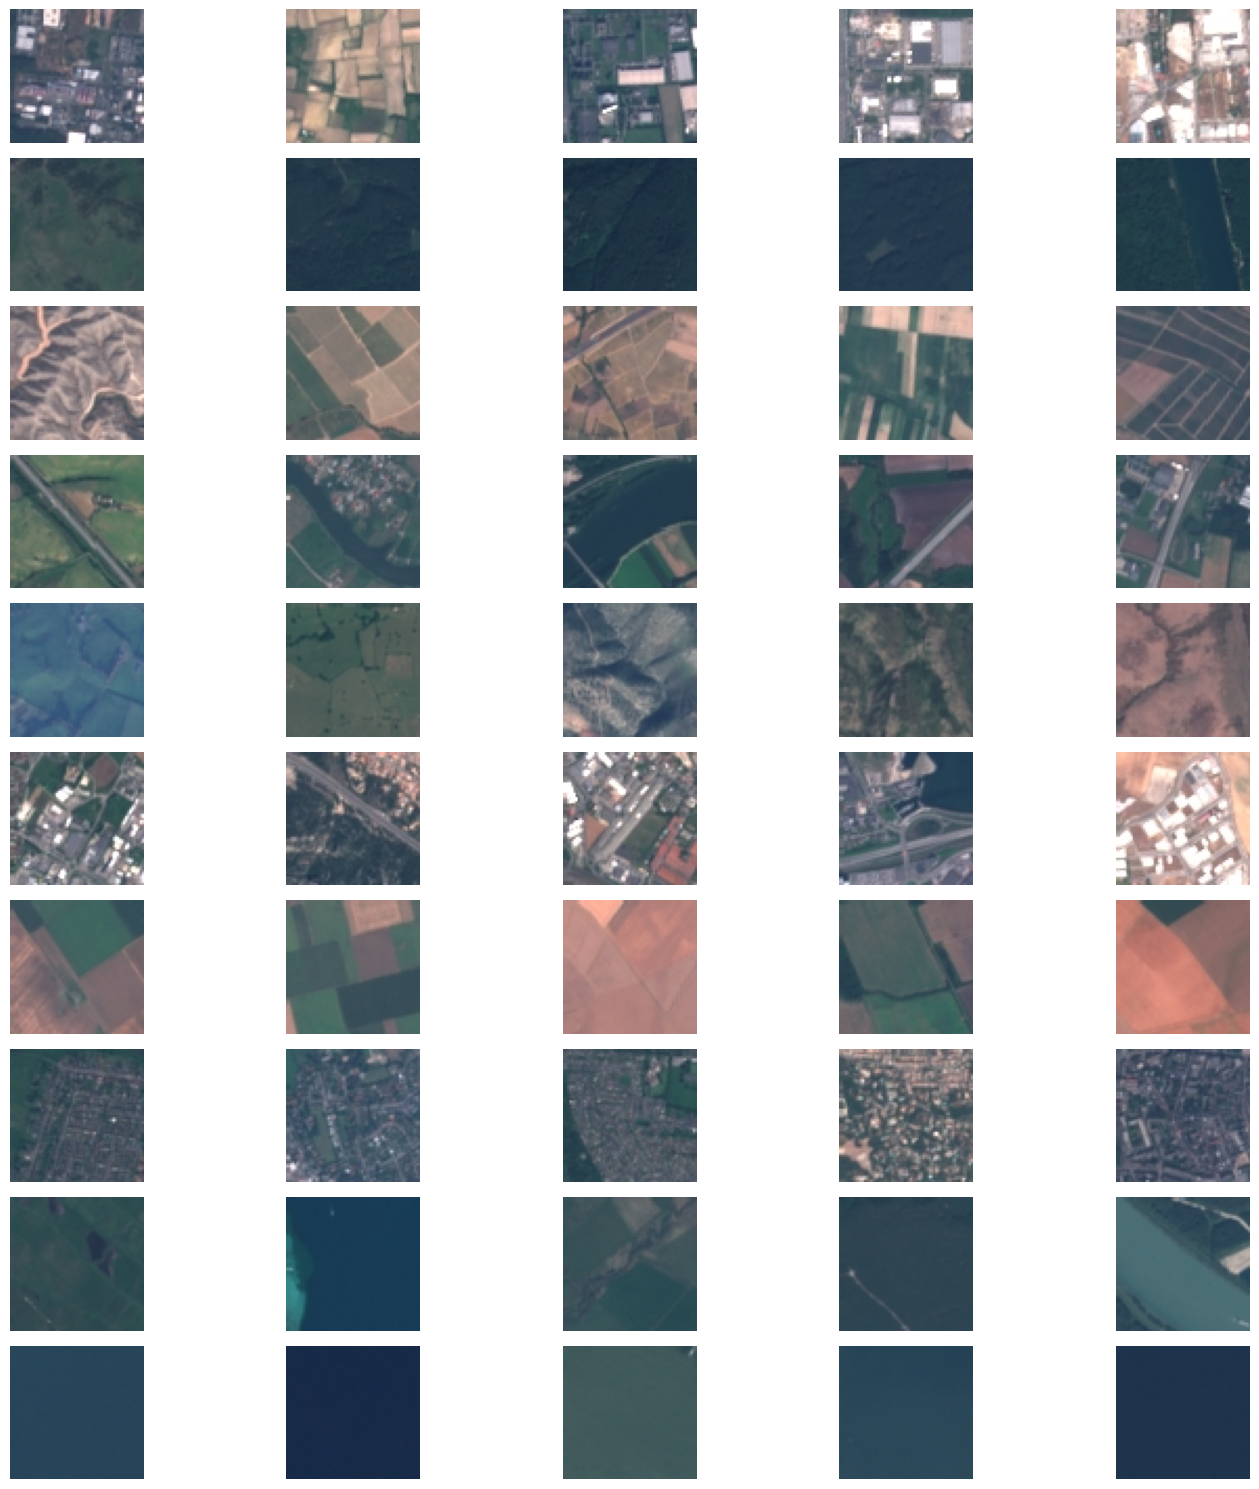

Αποτελέσματα από Pixels:


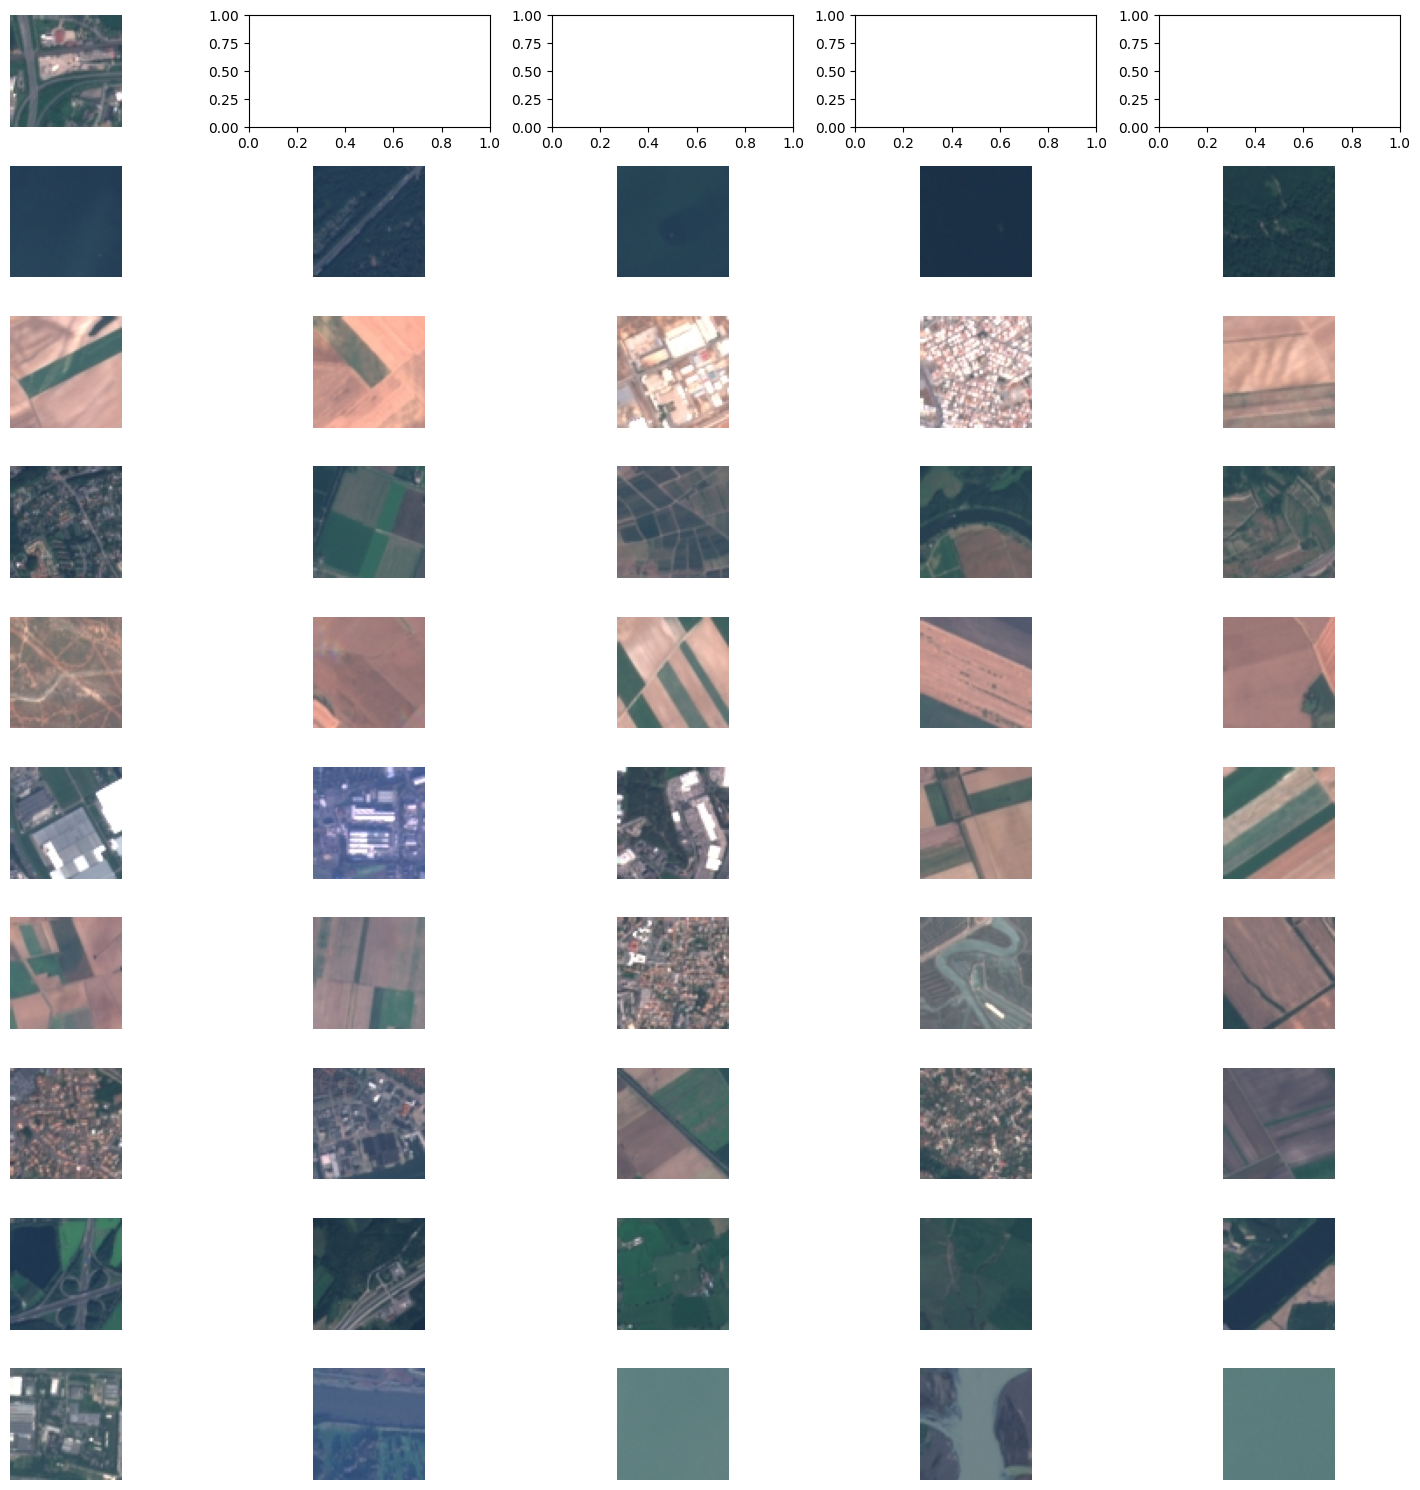

In [16]:
import matplotlib.pyplot as plt
import random
from PIL import Image

def visualize_clusters(image_paths, cluster_labels, num_clusters, samples_per_cluster):
    fig, axes = plt.subplots(num_clusters, samples_per_cluster, figsize=(15, 15))

    for cluster in range(num_clusters):
        cluster_indices = np.where(cluster_labels == cluster)[0]
        if len(cluster_indices) == 0:
            print(f"Καμία εικόνα δεν ανήκει στη συστάδα {cluster}.")
            continue

        sampled_indices = random.sample(list(cluster_indices), min(samples_per_cluster, len(cluster_indices)))

        for i, idx in enumerate(sampled_indices):
            try:
                img = Image.open(image_paths[idx])  # Χρησιμοποιούμε PIL για μεγαλύτερη αξιοπιστία
                axes[cluster, i].imshow(img)
                axes[cluster, i].axis('off')
            except Exception as e:
                print(f"Σφάλμα κατά τη φόρτωση της εικόνας {image_paths[idx]}: {e}")
                axes[cluster, i].axis('off')

    plt.tight_layout()
    plt.show()

# Απόκτησε τις διαδρομές των εικόνων
image_paths = [os.path.join(data_dir, fname) for fname in dataset.filenames]

# Οπτικοποίηση αποτελεσμάτων για CNN
print("Αποτελέσματα από CNN:")
visualize_clusters(image_paths, cluster_labels_cnn, num_clusters, samples_per_cluster=5)

# Οπτικοποίηση αποτελεσμάτων για Pixels
print("Αποτελέσματα από Pixels:")
visualize_clusters(image_paths, cluster_labels_pixels, num_clusters, samples_per_cluster=5)

Ο διαχωρισμός των εικόνων σε συστάδες είναι πολύ εμφανής με τη χρήση του CNN και ικανοποιητικά εμφανής με τη μέθοδο ανάλυσης των pixels.

Στις εικόνες κάθε συστάδας του CNN φαίνονται ξεκάθαρα κοινά χαρακτηριστικά, ενώ στην ανάλυση των pixels υπάρχουν συστάδες στις οποίες δεν έχουν όλες οι εικόνες κοινά χαρακτηριστικά.

Οι συστάδες που δημιουργήθηκαν από τα χαρακτηριστικά του CNN είναι πολύ πιο συμπαγείς και έχουν ξεκάθαρο διαχωρισμό σε σχέση με αυτές που δημιουργήθηκαν από τις τιμές των pixel, οι οποίες είναι λιγότερο συμπαγείς και διακριτές, ενώ επιπλέον υπάρχουν συστάδες με διαφορετικά χαρακτηριστικά (χρώματα, μοτίβα, κλπ.).

Η χρήση των χαρακτηριστικών που εξήχθησαν από το CNN προφανώς βοήθησε στον καλύτερο διαχωρισμό των δεδομένων, γεγονός που φαίνεται από τα ARI των δύο μεθόδων. Τα χαρακτηριστικά αυτά βοηθούν στην καλύτερη διάκριση και συσταδοποίηση των εικόνων, καθώς αντικατοπτρίζουν υψηλού επιπέδου πλήροφορίες, όπως μορφές και μοτίβα, με αποτέλεσμα οι εικόνες να ομαδοποιούνται με χαρακτηριστικά που αντιλαμβάνεται καλύτερα το ανθρώπινο μάτι. Σε αντίθεση, τα pixels περίεχουν χαμηλού επιπέδου πλήροφορίες, όπως χρώματα και φωτεινότητα, μη κατάλληλες για ομαδοποίηση και σαφώς δύσκολα διακριτές από το ανθρώπινο μάτι.